# Stock Market Data and Analysis

Pull live data with yfinance and analyze prices, returns, and volatility.

## Goals

- Download prices for major stocks
- Plot with moving averages
- Compare cumulative returns
- Measure rolling volatility


## Stock Prices with Moving Averages

We download daily closes and overlay 50-day and 200-day moving averages. These are common technical indicators for trend following.


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Pull 1 year of daily stock data for 4 companies
TICKERS = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft', 
    'GOOGL': 'Google',
    'AMZN': 'Amazon'
}
DATA_PERIOD = '1y'

# Download the data
data = yf.download(list(TICKERS.keys()), period=DATA_PERIOD)['Close']

# Show the last 5 trading days
data.tail()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2026-03-27,248.800003,199.339996,274.339996,356.769989
2026-03-30,246.630005,200.949997,273.500000,358.959991
2026-03-31,253.789993,208.270004,287.559998,370.170013
2026-04-01,255.630005,210.570007,297.390015,369.369995
2026-04-02,255.919998,209.770004,295.769989,373.459991


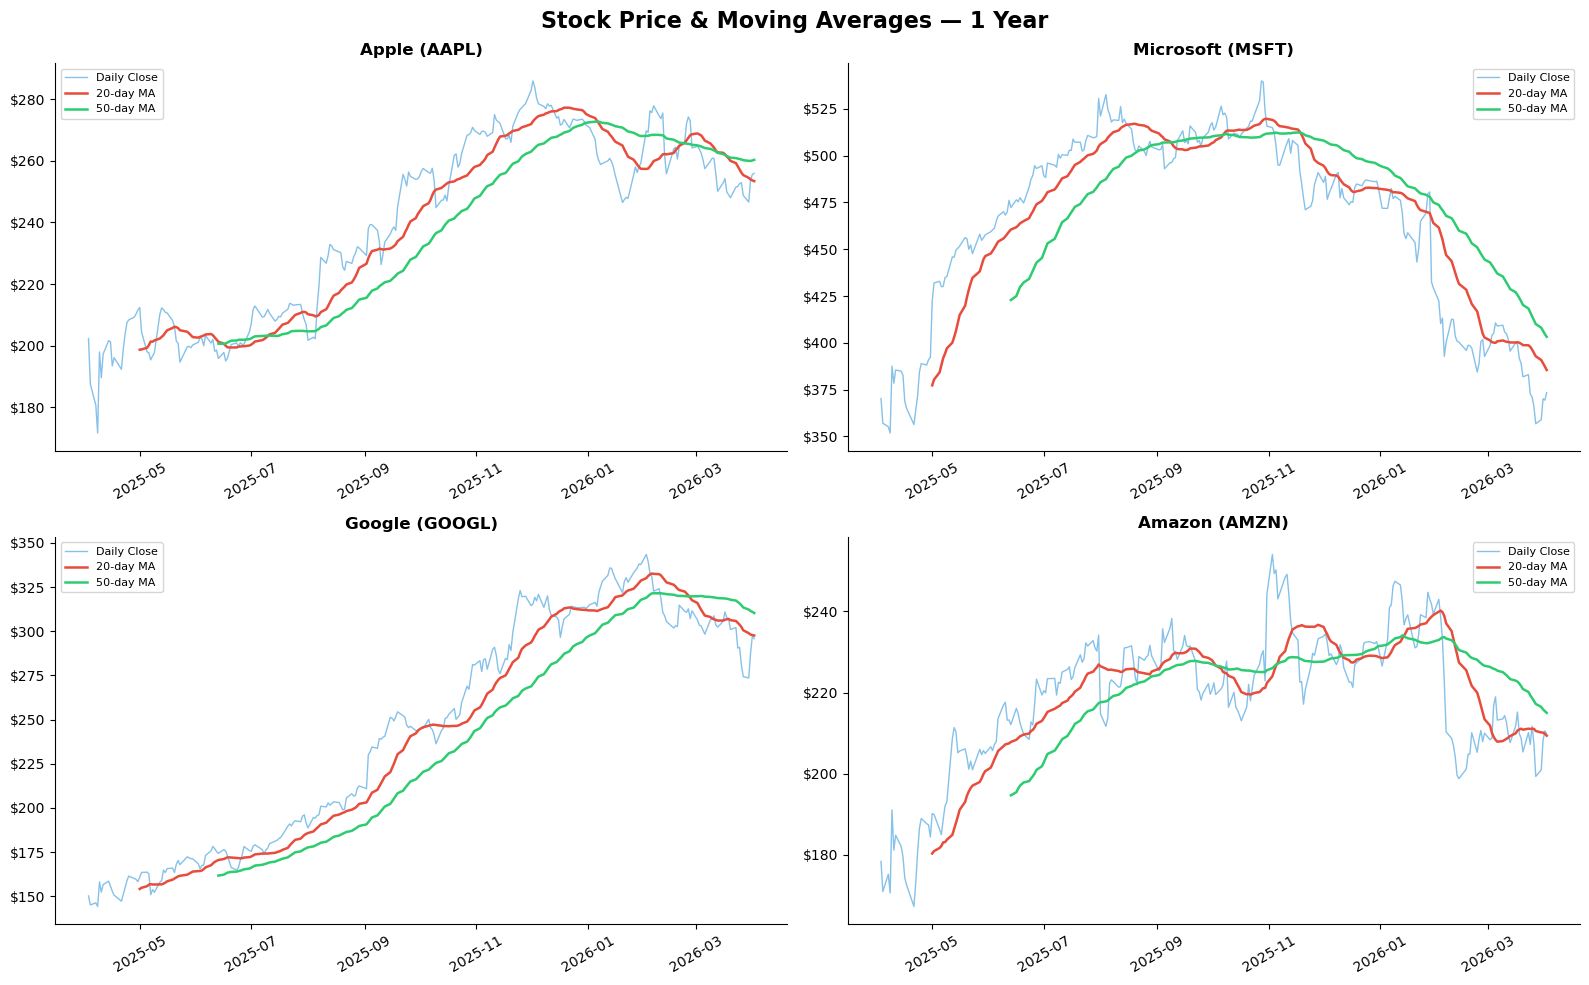

In [2]:
# Stock price chart with moving averages
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stock Price & Moving Averages — 1 Year', fontsize=16, fontweight='bold')

for idx, (ticker, name) in enumerate(tickers.items()):
    ax = axes[idx // 2][idx % 2]
    
    # Daily closing price
    ax.plot(data[ticker], color='#3498db', linewidth=1, alpha=0.6, label='Daily Close')
    
    # 20-day moving average (short-term trend)
    ma20 = data[ticker].rolling(window=20).mean()
    ax.plot(ma20, color='#e74c3c', linewidth=1.8, label='20-day MA')
    
    # 50-day moving average (medium-term trend)
    ma50 = data[ticker].rolling(window=50).mean()
    ax.plot(ma50, color='#2ecc71', linewidth=1.8, label='50-day MA')
    
    ax.set_title(f'{name} ({ticker})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/stock_prices_ma.png', dpi=150, bbox_inches='tight')
plt.show()

## Cumulative Returns

Shows the growth of $1 invested in each stock over the year. Useful for comparing total performance including compounding.


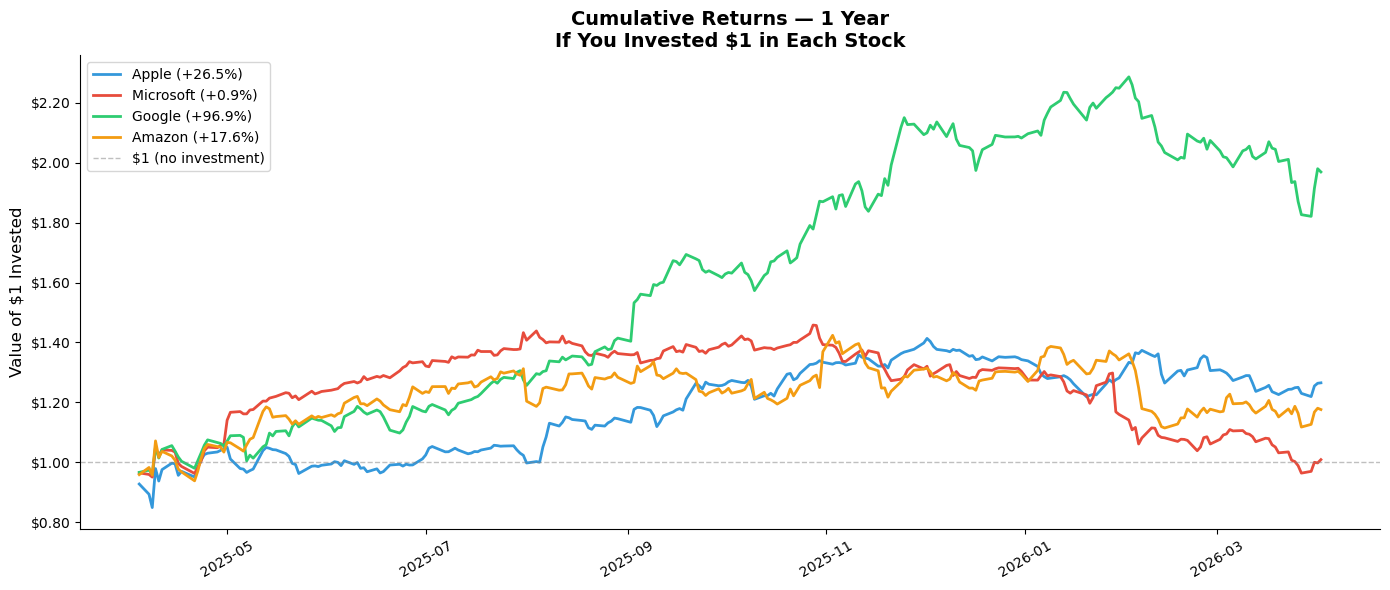

In [3]:
# Cumulative Returns — $1 invested in each stock, how did it grow?
daily_returns = data.pct_change()
cumulative_returns = (1 + daily_returns).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))

colors = {'AAPL': '#3498db', 'MSFT': '#e74c3c', 'GOOGL': '#2ecc71', 'AMZN': '#f39c12'}

for ticker, name in tickers.items():
    final_return = (cumulative_returns[ticker].iloc[-1] - 1) * 100
    ax.plot(cumulative_returns[ticker], color=colors[ticker], linewidth=2,
            label=f'{name} ({final_return:+.1f}%)')

# Baseline — your dollar stays flat if you did nothing
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='$1 (no investment)')

ax.set_ylabel('Value of $1 Invested', fontsize=12)
ax.set_title('Cumulative Returns — 1 Year\nIf You Invested $1 in Each Stock', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.2f}'))
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## Volatility

Rolling volatility measures how much prices swing. Higher vol means more risk (and potential reward).


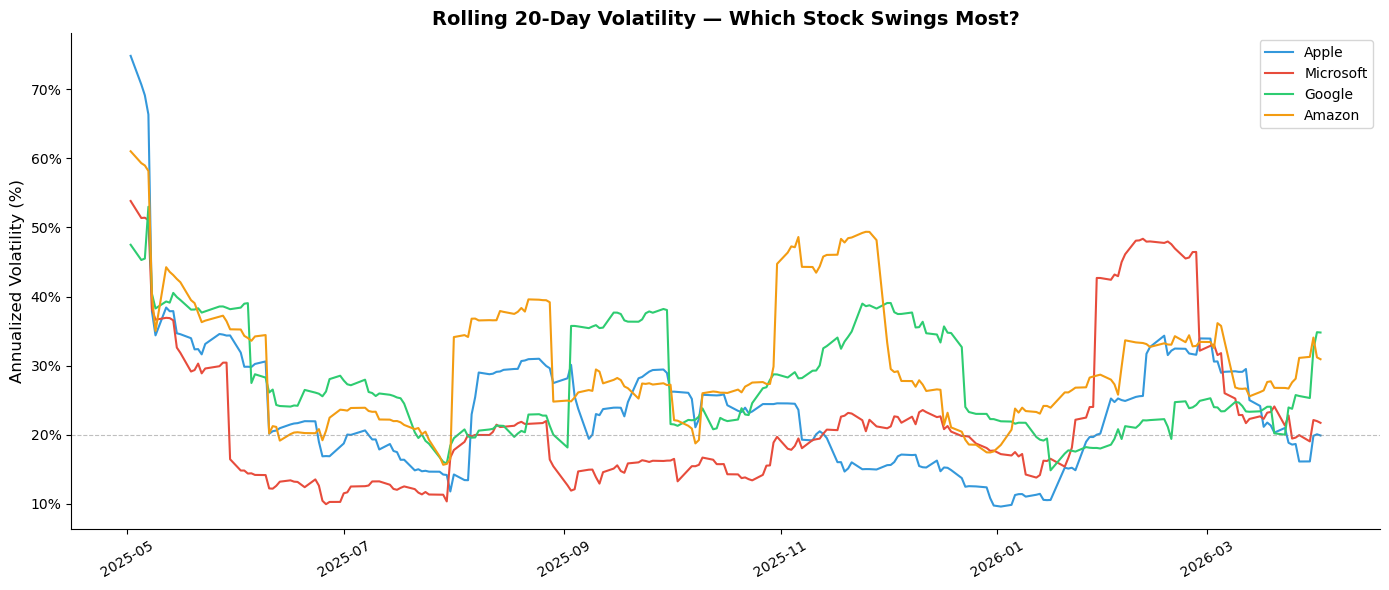

In [4]:
# Volatility comparison — how much does each stock swing?
rolling_vol = daily_returns.rolling(window=20).std() * (252 ** 0.5) * 100  # Annualized

fig, ax = plt.subplots(figsize=(14, 6))

for ticker, name in tickers.items():
    ax.plot(rolling_vol[ticker], color=colors[ticker], linewidth=1.5, label=name)

ax.set_ylabel('Annualized Volatility (%)', fontsize=12)
ax.set_title('Rolling 20-Day Volatility — Which Stock Swings Most?', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.tick_params(axis='x', rotation=30)
ax.axhline(y=20, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='~Average market volatility')

plt.tight_layout()
plt.savefig('../data/volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## Try This to Drill

- Tweak a constant (e.g. rates, years, sim count) in the code cells and re-run the visualizations.
- Observe how the charts and conclusions change. This is how the concepts become intuitive.
